# Notebook 03 — Preprocess + Patch Extraction

Prepares the bitemporal dataset:
1. Clips T1/T2 bands to Gironde bbox
2. Resamples 20m bands (B8A, B11, B12, SCL) to 10m grid
3. Applies cloud/shadow mask from SCL
4. Aligns labels (Hansen GFC) to same grid
5. Extracts 256×256 patches

**Output**: `data/patches/` — numpy arrays (.npy) for T1, T2, and masks  
**Environment**: local CPU  
**Runtime**: ~20-30 min

In [8]:
# === Cell 1: Imports & setup ===
import json
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling, calculate_default_transform
from rasterio.mask import mask as rio_mask
from rasterio.crs import CRS
from shapely.geometry import box, mapping
from pathlib import Path
from tqdm import tqdm

BASE        = Path('D:/GeoAI/forest-disturbance')
T1_DIR      = BASE / 'data/raw/sentinel2/T1_pre'
T2_DIR      = BASE / 'data/raw/sentinel2/T2_post'
LABELS_DIR  = BASE / 'data/raw/labels'
PATCHES_T1  = BASE / 'data/patches/images_t1'
PATCHES_T2  = BASE / 'data/patches/images_t2'
PATCHES_MSK = BASE / 'data/patches/masks'
for p in [PATCHES_T1, PATCHES_T2, PATCHES_MSK]:
    p.mkdir(parents=True, exist_ok=True)

with open(BASE / 'data/raw/sentinel2/scenes_metadata.json') as f:
    META = json.load(f)

BBOX       = META['bbox']          # [-1.45, 44.42, -0.42, 45.05]
TARGET_CRS = META['target_crs']    # 'EPSG:32630'
TARGET_RES = 10
PATCH_SIZE = 256
STRIDE     = 128    # 50% overlap

# SCL values to mask out: cloud shadow=3, cloud medium=8, cloud high=9, cirrus=10
CLOUD_VALUES = {3, 8, 9, 10}

# Band order for the 6-channel stack: B02, B03, B04, B8A, B11, B12
BAND_KEYS = ['B02', 'B03', 'B04', 'B8A', 'B11', 'B12']

print(f'T1 scene: {META["T1"]["scene_id"][:40]}...')
print(f'T2 scene: {META["T2"]["scene_id"][:40]}...')
print(f'Patch size: {PATCH_SIZE}x{PATCH_SIZE}  stride={STRIDE}')

T1 scene: S2A_MSIL2A_20220702T105631_R094_T30TXQ_2...
T2 scene: S2A_MSIL2A_20220920T105741_R094_T30TXQ_2...
Patch size: 256x256  stride=128


In [9]:
# === Cell 2: Build 6-band stack for one scene ===
def build_stack(scene_meta, out_dir, target_crs, target_res, bbox):
    """Clips, resamples to 10m, and stacks 6 bands into (6,H,W) array.
    Returns (stack_array, cloud_mask, transform, crs).
    """
    gironde_wgs84 = [mapping(box(*bbox))]
    bands = {}
    scl_band = None
    ref_transform = ref_shape = ref_crs = None

    all_keys = BAND_KEYS + ['SCL']
    for key in tqdm(all_keys, desc='Loading bands'):
        path = Path(scene_meta['band_files'][key])
        with rasterio.open(path) as src:
            # Clip to bbox (convert bbox to src CRS)
            from rasterio.warp import transform_geom
            geom_src = transform_geom('EPSG:4326', src.crs, gironde_wgs84[0])
            clipped, clip_transform = rio_mask(src, [geom_src], crop=True)
            clipped = clipped[0].astype(np.float32)
            clip_crs = src.crs

        # Reproject to TARGET_CRS at TARGET_RES (handles 10m and 20m bands uniformly)
        dst_transform, dst_w, dst_h = calculate_default_transform(
            clip_crs, target_crs, clipped.shape[1], clipped.shape[0],
            left=clip_transform.c, top=clip_transform.f,
            right=clip_transform.c + clip_transform.a * clipped.shape[1],
            bottom=clip_transform.f + clip_transform.e * clipped.shape[0],
            resolution=target_res)

        dst_array = np.zeros((dst_h, dst_w), dtype=np.float32)
        reproject(
            source=clipped,
            destination=dst_array,
            src_transform=clip_transform,
            src_crs=clip_crs,
            dst_transform=dst_transform,
            dst_crs=target_crs,
            resampling=Resampling.bilinear if key != 'SCL' else Resampling.nearest)

        if ref_transform is None:
            ref_transform = dst_transform
            ref_shape     = (dst_h, dst_w)
            ref_crs       = target_crs
        else:
            # All bands must match reference shape (crop/pad 1px if needed)
            dst_array = dst_array[:ref_shape[0], :ref_shape[1]]

        if key == 'SCL':
            scl_band = dst_array
        else:
            bands[key] = dst_array

    # Stack in fixed order: B02, B03, B04, B8A, B11, B12
    stack = np.stack([bands[k] for k in BAND_KEYS], axis=0)   # (6, H, W)

    # Cloud mask: True = valid pixel
    cloud_mask = ~np.isin(scl_band.astype(np.uint8), list(CLOUD_VALUES))

    print(f'Stack shape: {stack.shape}  cloud-free: {cloud_mask.mean()*100:.1f}%')
    return stack, cloud_mask, ref_transform, ref_crs


print('Building T1 stack...')
t1_stack, t1_cloud, t1_transform, t1_crs = build_stack(META['T1'], T1_DIR, TARGET_CRS, TARGET_RES, BBOX)

print('Building T2 stack...')
t2_stack, t2_cloud, t2_transform, t2_crs = build_stack(META['T2'], T2_DIR, TARGET_CRS, TARGET_RES, BBOX)

Building T1 stack...


Loading bands:   0%|          | 0/7 [00:00<?, ?it/s]

Loading bands: 100%|██████████| 7/7 [00:19<00:00,  2.76s/it]


Stack shape: (6, 7206, 8334)  cloud-free: 99.9%
Building T2 stack...


Loading bands: 100%|██████████| 7/7 [00:19<00:00,  2.75s/it]


Stack shape: (6, 7206, 8334)  cloud-free: 100.0%


In [10]:
# === Cell 3: Load and align forest loss mask to same grid ===
label_src_path = LABELS_DIR / 'forest_loss_2022_gironde.tif'

H, W = t1_stack.shape[1], t1_stack.shape[2]
label_aligned = np.zeros((H, W), dtype=np.uint8)

with rasterio.open(label_src_path) as src:
    reproject(
        source=rasterio.band(src, 1),
        destination=label_aligned,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=t1_transform,
        dst_crs=t1_crs,
        dst_shape=(H, W),
        resampling=Resampling.nearest)

# Valid pixel mask: cloud-free in BOTH T1 and T2
valid_mask = t1_cloud & t2_cloud

print(f'Label grid   : {H}x{W}')
print(f'Forest loss  : {label_aligned.sum():,} px  ({label_aligned.mean()*100:.2f}%)')
print(f'Valid pixels : {valid_mask.mean()*100:.1f}%')

Label grid   : 7206x8334
Forest loss  : 4,668,611 px  (7.77%)
Valid pixels : 99.9%


In [11]:
# === Cell 4: Extract patches ===
# Patches must have: >50% valid pixels AND label coverage between 1% and 95%
# (avoids all-background and all-foreground patches)
# Background patches (0% forest loss) kept at 3:1 ratio vs positive patches

def extract_patches(t1, t2, label, valid, patch_size, stride):
    H, W = label.shape
    pos_patches = []
    neg_patches = []

    for row in range(0, H - patch_size + 1, stride):
        for col in range(0, W - patch_size + 1, stride):
            sl = (slice(row, row+patch_size), slice(col, col+patch_size))

            v = valid[sl].mean()
            if v < 0.50:       # skip if >50% clouds
                continue

            lbl = label[sl]
            lrate = lbl.mean()

            patch = {
                't1':   t1[:, row:row+patch_size, col:col+patch_size],
                't2':   t2[:, row:row+patch_size, col:col+patch_size],
                'mask': lbl,
                'row':  row, 'col': col,
            }

            if 0.01 <= lrate <= 0.95:
                pos_patches.append(patch)
            elif lrate < 0.01:
                neg_patches.append(patch)

    # Subsample negatives 3:1 ratio
    import random; random.seed(42)
    n_neg = min(len(neg_patches), len(pos_patches) * 3)
    neg_patches = random.sample(neg_patches, n_neg)

    return pos_patches + neg_patches


print('Extracting patches...')
patches = extract_patches(t1_stack, t2_stack, label_aligned, valid_mask, PATCH_SIZE, STRIDE)
print(f'Total patches: {len(patches)}')

pos = sum(1 for p in patches if p['mask'].mean() >= 0.01)
print(f'  Positive (forest loss): {pos}')
print(f'  Negative (no loss)    : {len(patches) - pos}')

Extracting patches...
Total patches: 3224
  Positive (forest loss): 806
  Negative (no loss)    : 2418


In [12]:
# === Cell 5: Save patches as .npy ===
import random
random.seed(42)
random.shuffle(patches)

for i, p in enumerate(tqdm(patches, desc='Saving')):
    name = f'patch_{i:05d}_r{p["row"]}_c{p["col"]}.npy'
    np.save(PATCHES_T1  / name, p['t1'].astype(np.float32))
    np.save(PATCHES_T2  / name, p['t2'].astype(np.float32))
    np.save(PATCHES_MSK / name, p['mask'].astype(np.uint8))

# Save split indices (80% train, 20% val)
n = len(patches)
n_train = int(n * 0.8)
names   = sorted(PATCHES_MSK.glob('*.npy'))
split   = {'train': [p.name for p in names[:n_train]],
           'val':   [p.name for p in names[n_train:]]}
with open(BASE / 'data/patches/split.json', 'w') as f:
    import json; json.dump(split, f, indent=2)

print(f'Saved {len(patches)} patches')
print(f'Train: {n_train}  Val: {n - n_train}')

Saving: 100%|██████████| 3224/3224 [00:22<00:00, 141.25it/s]

Saved 3224 patches
Train: 2579  Val: 645


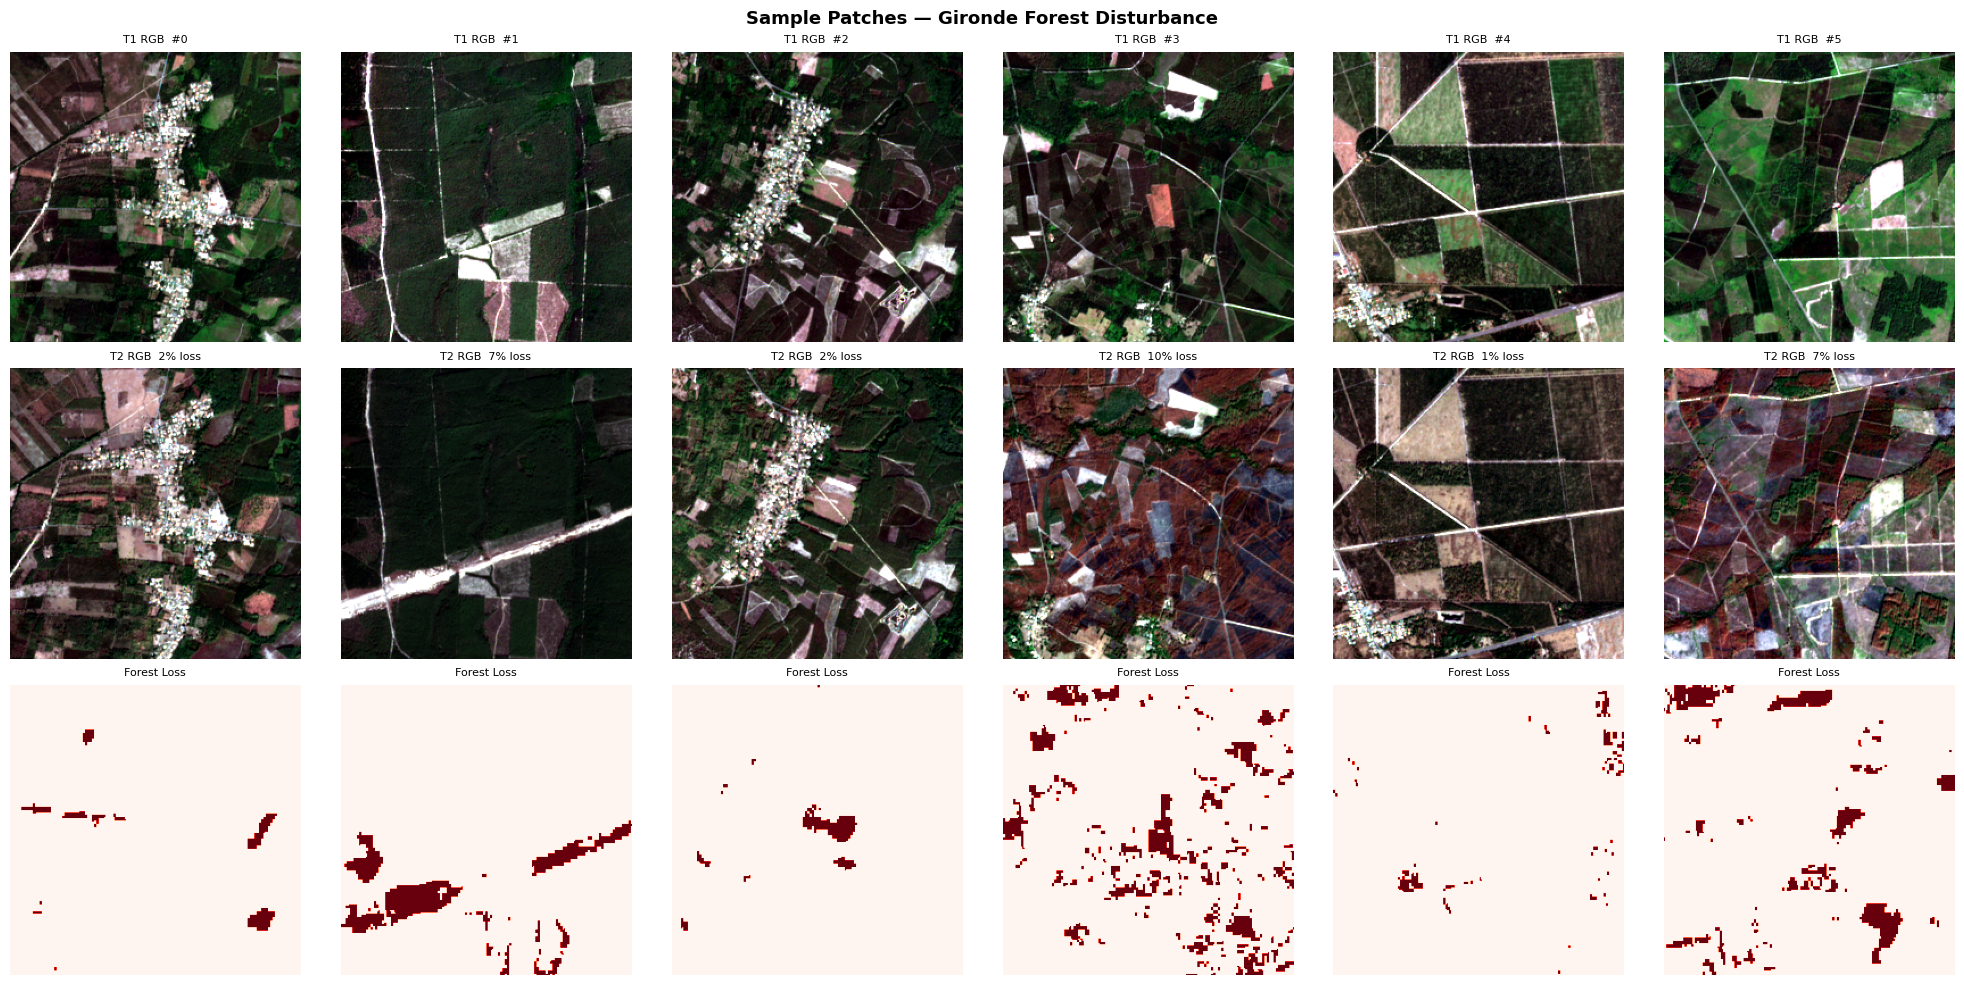

Saved: results/check_patches.png


In [13]:
# === Cell 6: Quick visual check — 6 random positive patches ===
import matplotlib.pyplot as plt

pos_patches = [p for p in patches if p['mask'].mean() >= 0.01]
sample = pos_patches[:6]

fig, axes = plt.subplots(3, 6, figsize=(20, 10))

def norm(x):
    v = x[x > 0]; lo, hi = np.percentile(v, [2, 98]) if len(v) else (0, 1)
    return np.clip((x - lo) / (hi - lo + 1e-6), 0, 1)

for i, p in enumerate(sample):
    # Row 0: T1 RGB
    rgb1 = np.dstack([norm(p['t1'][2]/10000), norm(p['t1'][1]/10000), norm(p['t1'][0]/10000)])
    axes[0, i].imshow(rgb1); axes[0, i].set_title(f'T1 RGB  #{i}', fontsize=8); axes[0, i].axis('off')
    # Row 1: T2 RGB
    rgb2 = np.dstack([norm(p['t2'][2]/10000), norm(p['t2'][1]/10000), norm(p['t2'][0]/10000)])
    axes[1, i].imshow(rgb2); axes[1, i].set_title(f'T2 RGB  {p["mask"].mean()*100:.0f}% loss', fontsize=8); axes[1, i].axis('off')
    # Row 2: Label
    axes[2, i].imshow(p['mask'], cmap='Reds', vmin=0, vmax=1); axes[2, i].set_title('Forest Loss', fontsize=8); axes[2, i].axis('off')

axes[0, 0].set_ylabel('T1 (pre-fire)', fontsize=10, rotation=90, labelpad=10)
axes[1, 0].set_ylabel('T2 (post-fire)', fontsize=10, rotation=90, labelpad=10)
axes[2, 0].set_ylabel('Label', fontsize=10, rotation=90, labelpad=10)

plt.suptitle('Sample Patches — Gironde Forest Disturbance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'results/check_patches.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: results/check_patches.png')